In [1]:
import pandas as pd
import numpy as np

In [2]:
train_df = pd.read_csv("../data/train_dataset.csv")
val_df = pd.read_csv("../data/val_dataset.csv")
test_df = pd.read_csv("../data/test_dataset.csv")

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Train: 41999  Val: 6000  Test: 12000


In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["sentiment"]
y_val = val_df["sentiment"]
y_test = test_df["sentiment"]

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,} features")
print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

Vocabulary size: 61,581 features
X_train: (41999, 61581)  X_val: (6000, 61581)  X_test: (12000, 61581)


In [4]:
model = SGDClassifier(
    loss="log_loss",
    random_state=42,
    warm_start=True,
    max_iter=1,
    tol=None,
)

classes = np.array(["negative", "neutral", "positive"])

max_epochs = 100
patience = 5
best_val_acc = 0
best_epoch = 0
no_improve = 0

history = {"epoch": [], "train_acc": [], "val_acc": [], "val_f1": []}

for epoch in range(1, max_epochs + 1):
    model.partial_fit(X_train, y_train, classes=classes)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    val_f1 = f1_score(y_val, model.predict(X_val), average="macro", zero_division=0)

    history["epoch"].append(epoch)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}  |  train_acc: {train_acc:.4f}  |  val_acc: {val_acc:.4f}  |  val_f1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_coef = model.coef_.copy()
        best_intercept = model.intercept_.copy()
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}. Best val_acc: {best_val_acc:.4f} at epoch {best_epoch}")
        break

model.coef_ = best_coef
model.intercept_ = best_intercept

print(f"\nRestored weights from epoch {best_epoch}")

Epoch   1  |  train_acc: 0.7012  |  val_acc: 0.6712  |  val_f1: 0.6546
Epoch   5  |  train_acc: 0.7783  |  val_acc: 0.6987  |  val_f1: 0.6905
Epoch  10  |  train_acc: 0.8369  |  val_acc: 0.7373  |  val_f1: 0.7289
Epoch  15  |  train_acc: 0.8422  |  val_acc: 0.7413  |  val_f1: 0.7298
Epoch  20  |  train_acc: 0.8497  |  val_acc: 0.7488  |  val_f1: 0.7384
Epoch  25  |  train_acc: 0.8533  |  val_acc: 0.7505  |  val_f1: 0.7407
Epoch  30  |  train_acc: 0.8567  |  val_acc: 0.7537  |  val_f1: 0.7447

Early stopping at epoch 34. Best val_acc: 0.7542 at epoch 29

Restored weights from epoch 29


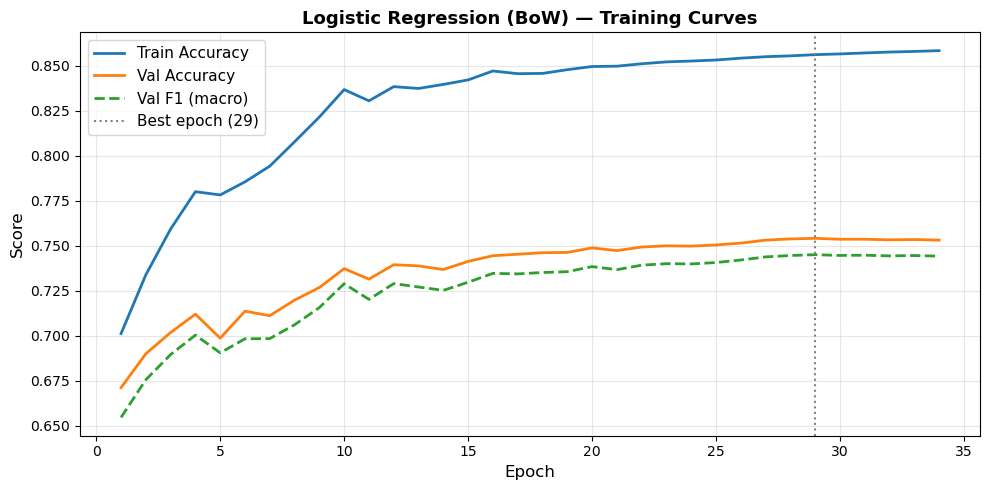

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["epoch"], history["train_acc"], label="Train Accuracy", linewidth=2)
ax.plot(history["epoch"], history["val_acc"], label="Val Accuracy", linewidth=2)
ax.plot(history["epoch"], history["val_f1"], label="Val F1 (macro)", linewidth=2, linestyle="--")
ax.axvline(x=best_epoch, color="gray", linestyle=":", label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Logistic Regression (BoW): Training Curves", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
y_pred = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=["negative", "neutral", "positive"]))

Test Accuracy: 0.7506

              precision    recall  f1-score   support

    negative       0.77      0.78      0.78      4050
     neutral       0.74      0.60      0.66      3451
    positive       0.74      0.84      0.78      4499

    accuracy                           0.75     12000
   macro avg       0.75      0.74      0.74     12000
weighted avg       0.75      0.75      0.75     12000




--- super_short (4000 samples) ---
  Accuracy:  0.718
  F1 (macro): 0.707
  F1 per class: neg=0.722  neu=0.632  pos=0.766

--- short (4001 samples) ---
  Accuracy:  0.756
  F1 (macro): 0.750
  F1 per class: neg=0.785  neu=0.678  pos=0.787

--- medium (2000 samples) ---
  Accuracy:  0.786
  F1 (macro): 0.774
  F1 per class: neg=0.812  neu=0.694  pos=0.816

--- long (1999 samples) ---
  Accuracy:  0.770
  F1 (macro): 0.758
  F1 per class: neg=0.819  neu=0.665  pos=0.790


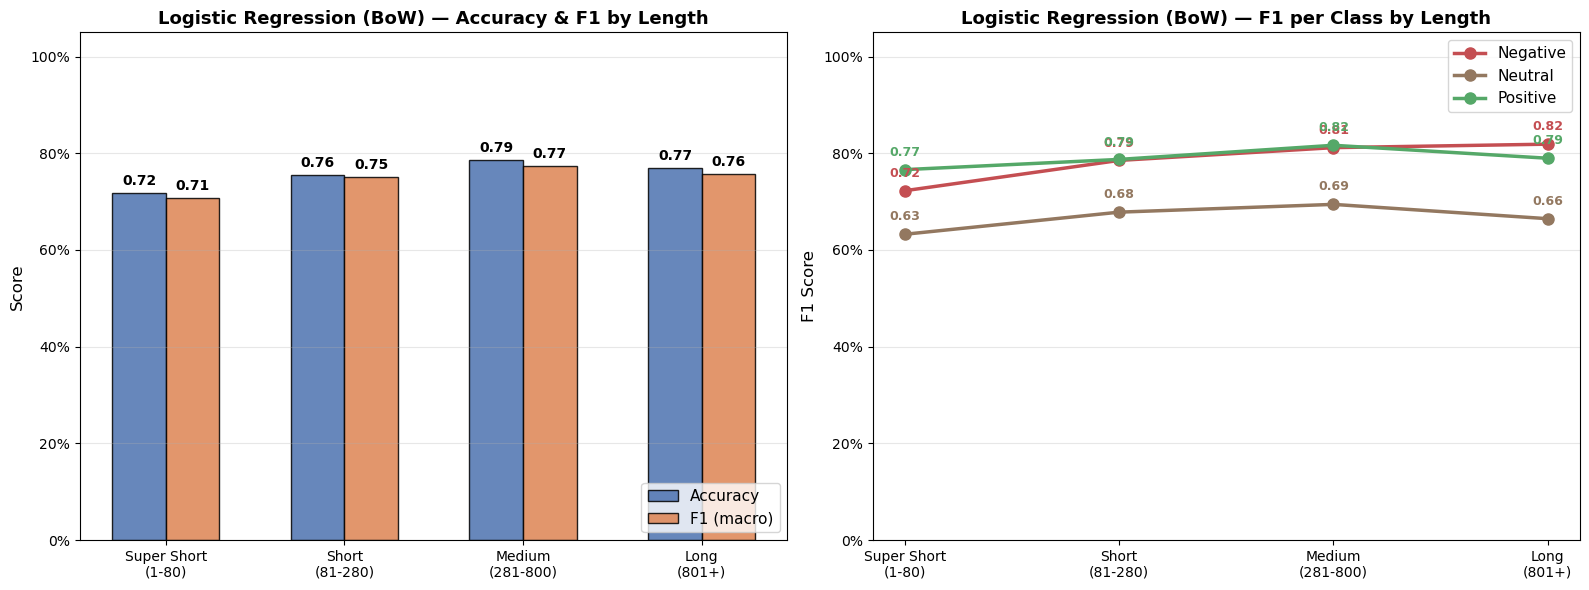

In [7]:
import matplotlib.ticker as mticker

bucket_names = ["super_short", "short", "medium", "long"]
bucket_labels = ["Super Short\n(1-80)", "Short\n(81-280)", "Medium\n(281-800)", "Long\n(801+)"]

accuracies = []
f1_macros = []
f1_per_class = {"negative": [], "neutral": [], "positive": []}

for bucket in bucket_names:
    mask = test_df["bucket"] == bucket
    y_true_b = y_test[mask]
    y_pred_b = y_pred[mask]

    acc = accuracy_score(y_true_b, y_pred_b)
    f1_mac = f1_score(y_true_b, y_pred_b, average="macro", zero_division=0)
    accuracies.append(acc)
    f1_macros.append(f1_mac)

    f1_cls = f1_score(y_true_b, y_pred_b, average=None,
                      labels=["negative", "neutral", "positive"], zero_division=0)
    for j, cls in enumerate(["negative", "neutral", "positive"]):
        f1_per_class[cls].append(f1_cls[j])

    print(f"\n--- {bucket} ({mask.sum()} samples) ---")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  F1 (macro): {f1_mac:.3f}")
    print(f"  F1 per class: neg={f1_per_class['negative'][-1]:.3f}  "
          f"neu={f1_per_class['neutral'][-1]:.3f}  "
          f"pos={f1_per_class['positive'][-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(bucket_names))
width = 0.3

bars1 = ax1.bar(x - width/2, accuracies, width, label="Accuracy",
                color="#4C72B0", edgecolor="black", alpha=0.85)
bars2 = ax1.bar(x + width/2, f1_macros, width, label="F1 (macro)",
                color="#DD8452", edgecolor="black", alpha=0.85)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(bucket_labels, fontsize=10)
ax1.set_ylabel("Score", fontsize=12)
ax1.set_title("Logistic Regression (BoW): Accuracy & F1 by Length", fontsize=13, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.legend(fontsize=11, loc="lower right")
ax1.grid(axis="y", alpha=0.3)

colors = {"negative": "#C44E52", "neutral": "#937860", "positive": "#55A868"}
for cls, color in colors.items():
    ax2.plot(x, f1_per_class[cls], marker="o", markersize=8, linewidth=2.5,
             label=cls.capitalize(), color=color)
    for i, val in enumerate(f1_per_class[cls]):
        ax2.annotate(f"{val:.2f}", (x[i], val), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9, fontweight="bold", color=color)

ax2.set_xticks(x)
ax2.set_xticklabels(bucket_labels, fontsize=10)
ax2.set_ylabel("F1 Score", fontsize=12)
ax2.set_title("Logistic Regression (BoW): F1 per Class by Length", fontsize=13, fontweight="bold")
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=11)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()